In [2]:
# Instalacja
!pip install -q tensorflow opencv-python pillow

# Import bibliotek - URUCHOM TO NAJPIERW!
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from google.colab import files
import shutil

print(f"TensorFlow: {tf.__version__}")

TensorFlow: 2.20.0


In [3]:
print("Wybierz 20 plików: setosa1.jpg ... setosa20.jpg")
uploaded = files.upload()
os.makedirs('dataset/setosa', exist_ok=True)
for filename in uploaded.keys():
    shutil.move(filename, f'dataset/setosa/{filename}')
print(f"Wgrano {len(uploaded)} zdjęć setosa")

Wybierz 20 plików: setosa1.jpg ... setosa20.jpg


Saving setosa (1).jpg to setosa (1).jpg
Saving setosa (2).jpg to setosa (2).jpg
Saving setosa (3).JPG to setosa (3).JPG
Saving setosa (4).jpg to setosa (4).jpg
Saving setosa (5).jpg to setosa (5).jpg
Saving setosa (6).jpg to setosa (6).jpg
Saving setosa (7).jpg to setosa (7).jpg
Saving setosa (8).jpg to setosa (8).jpg
Saving setosa (9).jpg to setosa (9).jpg
Saving setosa (10).jpg to setosa (10).jpg
Saving setosa (11).jpg to setosa (11).jpg
Saving setosa (12).jpg to setosa (12).jpg
Saving setosa (13).jpg to setosa (13).jpg
Saving setosa (14).jpg to setosa (14).jpg
Saving setosa (15).jpg to setosa (15).jpg
Saving setosa (16).jpg to setosa (16).jpg
Saving setosa (17).JPG to setosa (17).JPG
Saving setosa (18).jpg to setosa (18).jpg
Saving setosa (19).jpg to setosa (19).jpg
Saving setosa (20).jpg to setosa (20).jpg
Wgrano 20 zdjęć setosa


In [4]:
print("Wybierz 20 plików: versicolor1.jpg ... versicolor20.jpg")
uploaded = files.upload()
os.makedirs('dataset/versicolor', exist_ok=True)
for filename in uploaded.keys():
    shutil.move(filename, f'dataset/versicolor/{filename}')
print(f"Wgrano {len(uploaded)} zdjęć versicolor")

Wybierz 20 plików: versicolor1.jpg ... versicolor20.jpg


Saving versicolor (1).jpg to versicolor (1).jpg
Saving versicolor (2).jpg to versicolor (2).jpg
Saving versicolor (3).jpg to versicolor (3).jpg
Saving versicolor (4).jpg to versicolor (4).jpg
Saving versicolor (5).jpg to versicolor (5).jpg
Saving versicolor (6).jpg to versicolor (6).jpg
Saving versicolor (7).jpg to versicolor (7).jpg
Saving versicolor (8).jpg to versicolor (8).jpg
Saving versicolor (9).jpg to versicolor (9).jpg
Saving versicolor (10).jpg to versicolor (10).jpg
Saving versicolor (11).jpg to versicolor (11).jpg
Saving versicolor (12).jpg to versicolor (12).jpg
Saving versicolor (13).jpg to versicolor (13).jpg
Saving versicolor (14).jpg to versicolor (14).jpg
Saving versicolor (15).jpg to versicolor (15).jpg
Saving versicolor (16).jpg to versicolor (16).jpg
Saving versicolor (17).jpg to versicolor (17).jpg
Saving versicolor (18).jpg to versicolor (18).jpg
Saving versicolor (19).jpg to versicolor (19).jpg
Saving versicolor (20).jpg to versicolor (20).jpg
Wgrano 20 zdjęć ve

In [5]:
print("Wybierz 20 plików: virginica1.jpg ... virginica20.jpg")
uploaded = files.upload()
os.makedirs('dataset/virginica', exist_ok=True)
for filename in uploaded.keys():
    shutil.move(filename, f'dataset/virginica/{filename}')
print(f"✅ Wgrano {len(uploaded)} zdjęć virginica")

Wybierz 20 plików: virginica1.jpg ... virginica20.jpg


Saving virginica (1).jpg to virginica (1).jpg
Saving virginica (2).jpg to virginica (2).jpg
Saving virginica (3).jpg to virginica (3).jpg
Saving virginica (4).jpg to virginica (4).jpg
Saving virginica (5).jpg to virginica (5).jpg
Saving virginica (6).jpg to virginica (6).jpg
Saving virginica (7).jpg to virginica (7).jpg
Saving virginica (8).jpg to virginica (8).jpg
Saving virginica (9).jpg to virginica (9).jpg
Saving virginica (10).jpg to virginica (10).jpg
Saving virginica (11).jpg to virginica (11).jpg
Saving virginica (12).jpg to virginica (12).jpg
Saving virginica (13).jpg to virginica (13).jpg
Saving virginica (14).jpg to virginica (14).jpg
Saving virginica (15).jpg to virginica (15).jpg
Saving virginica (16).jpg to virginica (16).jpg
Saving virginica (17).jpg to virginica (17).jpg
Saving virginica (18).jpg to virginica (18).jpg
Saving virginica (19).jpg to virginica (19).jpg
Saving virginica (20).jpg to virginica (20).jpg
✅ Wgrano 20 zdjęć virginica


In [7]:
IMG_SIZE = 150

In [9]:
from sklearn.model_selection import train_test_split

def split_dataset(source_dir, train_dir, test_dir, test_size=0.2):
 """Dzieli dataset na train/test zachowując strukturę katalogów"""
 for class_name in os.listdir(source_dir):
  class_path = os.path.join(source_dir, class_name)
  if not os.path.isdir(class_path):
   continue

  images = [f for f in os.listdir(class_path) if f.endswith(('.jpg',
'.jpeg', '.png'))]
  train_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)

  os.makedirs(f'{train_dir}/{class_name}', exist_ok=True)
  os.makedirs(f'{test_dir}/{class_name}', exist_ok=True)

  for img in train_imgs:
   shutil.copy(f'{class_path}/{img}', f'{train_dir}/{class_name}/{img}')
  for img in test_imgs:
   shutil.copy(f'{class_path}/{img}', f'{test_dir}/{class_name}/{img}')

  print(f"✅ Train: {len(train_imgs)*3} | Test: {len(test_imgs)*3}")

split_dataset('dataset', 'dataset_split/train', 'dataset_split/test')

✅ Train: 42 | Test: 12
✅ Train: 48 | Test: 12
✅ Train: 48 | Test: 12


In [10]:
# Augmentacja dla treningu
train_datagen = ImageDataGenerator(
 rescale=1./255,
 rotation_range=40,
 width_shift_range=0.2,
 height_shift_range=0.2,
 shear_range=0.2,
 zoom_range=0.2,
 horizontal_flip=True,
 fill_mode='nearest'
)

# Tylko normalizacja dla testu
test_datagen = ImageDataGenerator(rescale=1./255)

# Wczytanie danych
train_generator = train_datagen.flow_from_directory(
 'dataset_split/train',
 target_size=(IMG_SIZE, IMG_SIZE),
 batch_size=16,
 class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
 'dataset_split/test',
 target_size=(IMG_SIZE, IMG_SIZE),
 batch_size=16,
 class_mode='categorical',
 shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(f"\nKlasy: {class_names}")
print(f"Train samples: {train_generator.samples}")
print(f"Test samples: {test_generator.samples}")

Found 46 images belonging to 3 classes.
Found 12 images belonging to 3 classes.

Klasy: ['setosa', 'versicolor', 'virginica']
Train samples: 46
Test samples: 12


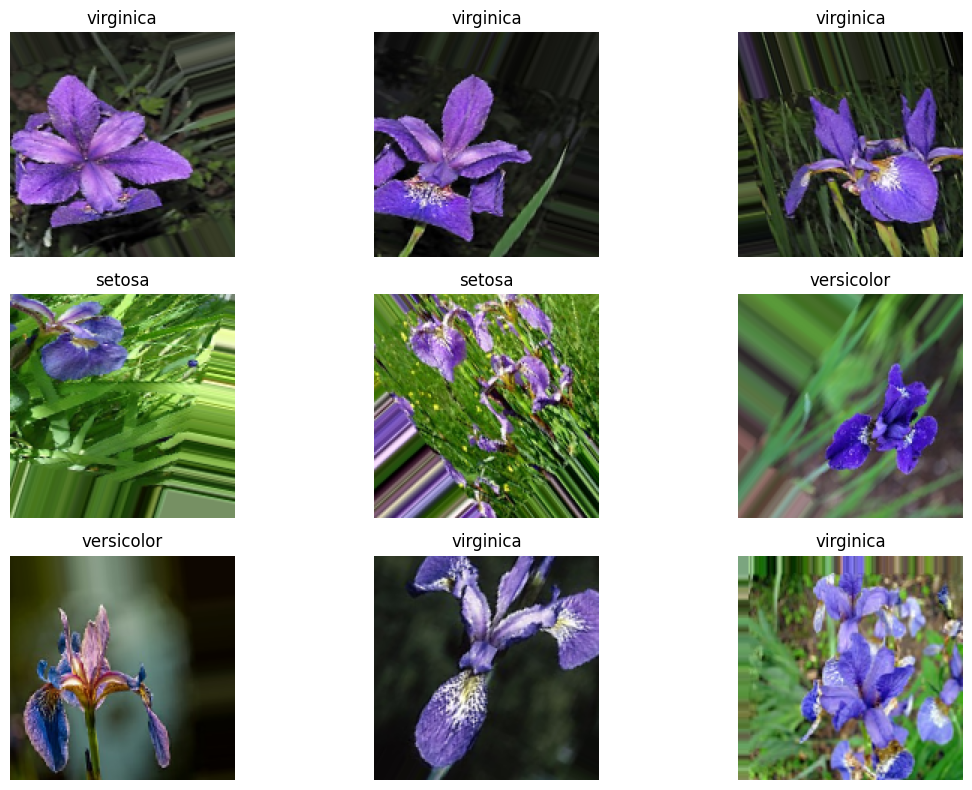

In [11]:
plt.figure(figsize=(12, 8))
for i in range(9):
 plt.subplot(3, 3, i+1)
 img_batch, label_batch = next(train_generator)
 plt.imshow(img_batch[0])
 plt.title(class_names[np.argmax(label_batch[0])])
 plt.axis('off')
plt.tight_layout()
plt.show()

In [12]:
from tensorflow import keras

model = keras.Sequential([
 # Block 1
 layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
 layers.MaxPooling2D((2, 2)),

 # Block 2
 layers.Conv2D(64, (3, 3), activation='relu'),
 layers.MaxPooling2D((2, 2)),

 # Block 3
 layers.Conv2D(128, (3, 3), activation='relu'),
 layers.MaxPooling2D((2, 2)),

 # Classifier
 layers.Flatten(),
 layers.Dropout(0.5),
 layers.Dense(128, activation='relu'),
 layers.Dropout(0.3),
 layers.Dense(3, activation='softmax')
])

# Kompilacja
model.compile(
 optimizer='adam',
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

# Podsumowanie
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,739 (18.42 MB)

 Trainable params: 4,828,739 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Callbacks
early_stop = keras.callbacks.EarlyStopping(
 monitor='val_loss',
 patience=5,
 restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
 monitor='val_loss',
 factor=0.5,
 patience=3,
 min_lr=1e-7
)

# Trenowanie
history = model.fit(
 train_generator,
 epochs=30,
 validation_data=test_generator,
 callbacks=[early_stop, reduce_lr]
)

print("\nTrenowanie zakończone!")

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 858ms/step - accuracy: 0.3261 - loss: 1.3339 - val_accuracy: 0.3333 - val_loss: 1.2542 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 971ms/step - accuracy: 0.3261 - loss: 1.1933 - val_accuracy: 0.3333 - val_loss: 1.0894 - learning_rate: 0.0010
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 709ms/step - accuracy: 0.3913 - loss: 1.0761 - val_accuracy: 0.5833 - val_loss: 1.0565 - learning_rate: 0.0010
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 692ms/step - accuracy: 0.4348 - loss: 1.0425 - val_accuracy: 0.5000 - val_loss: 0.9950 - learning_rate: 0.0010
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 699ms/step - accuracy: 0.3913 - loss: 1.0581 - val_accuracy: 0.5000 - val_loss: 0.9254 - learning_rate: 0.0010
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 774ms/step - accuracy: 0.5217 - loss: 1.0113 - val_accuracy: 0.5833 - val_loss: 1.0520 - learning_rate: 0.0010
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.4348 - loss: 0.9658 - val_accuracy: 0.5

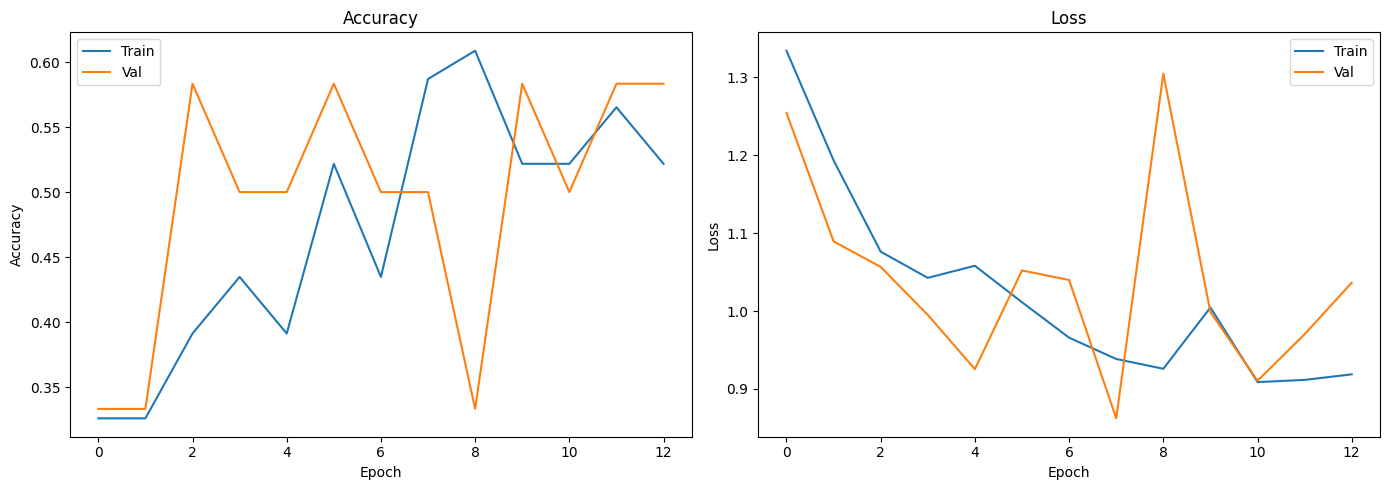

In [14]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss')

plt.tight_layout()
plt.show()

In [15]:
# Ewaluacja
test_generator.reset()
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.5000 - loss: 0.8623

Test Accuracy: 0.5000 (50.00%)
Test Loss: 0.8623


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


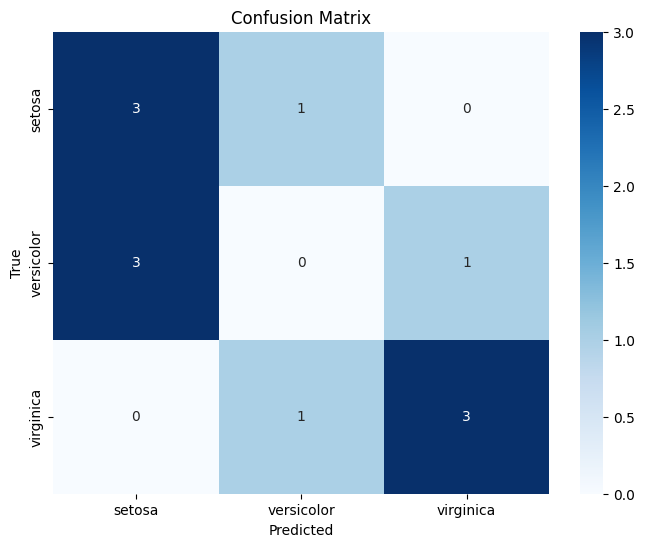

              precision    recall  f1-score   support

      setosa       0.50      0.75      0.60         4
  versicolor       0.00      0.00      0.00         4
   virginica       0.75      0.75      0.75         4

    accuracy                           0.50        12
   macro avg       0.42      0.50      0.45        12
weighted avg       0.42      0.50      0.45        12



In [16]:
# Predykcja
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
 xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_true, y_pred_classes, target_names=class_names))

Content-Type: image/png
Content Start (first 100 bytes): b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00\xb4\x00\x00\x00\xb4\x04\x03\x00\x00\x00\xcf\xe3\x1b\x01\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x000PLTE&\xa9\xe2\xff\xff\xff\xdf\xfc\xff&\xbd\xf2&\xa9\xe9\x9c\xf0\xff\xdf\xd8\xe9Q\xaa\xe3\xff\xf1\xf3\xff\xe3\xec'


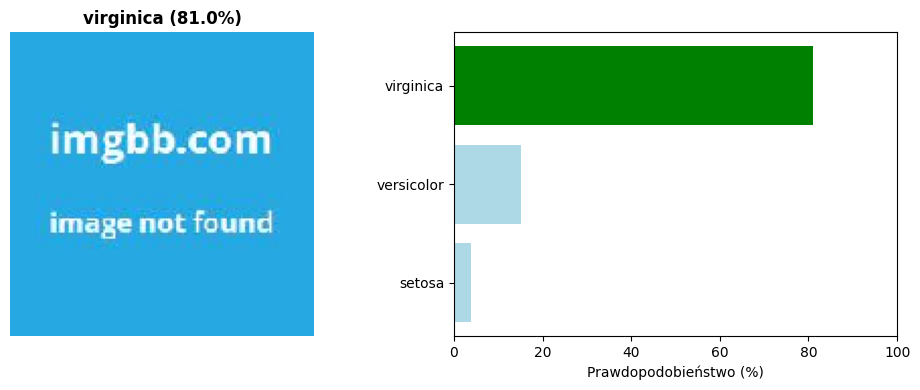

('virginica', np.float32(80.980034))

In [22]:
import requests
from io import BytesIO
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_flower(image_path):
 img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
 img_array = img_to_array(img) / 255.0
 img_array = np.expand_dims(img_array, axis=0)

 predictions = model.predict(img_array, verbose=0)
 predicted_idx = np.argmax(predictions[0])
 predicted_class = class_names[predicted_idx]
 confidence = predictions[0][predicted_idx] * 100

 plt.figure(figsize=(10, 4))
 plt.subplot(1, 2, 1)
 plt.imshow(img)
 plt.title(f"{predicted_class} ({confidence:.1f}%)", fontweight='bold')
 plt.axis('off')

 plt.subplot(1, 2, 2)
 colors = ['green' if i == predicted_idx else 'lightblue' for i in range(3)]
 plt.barh(class_names, predictions[0] * 100, color=colors)
 plt.xlabel('Prawdopodobieństwo (%)')
 plt.xlim(0, 100)
 plt.tight_layout()
 plt.show()

 return predicted_class, confidence

url = "https://i.ibb.co/CmLc0tX/Iris-versicolor-3.jpg" # Updated to a direct image link
response = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'})

print(f"Content-Type: {response.headers.get('Content-Type')}")
print(f"Content Start (first 100 bytes): {response.content[:100]}")

img = Image.open(BytesIO(response.content))
img = img.convert('RGB') # Convert image to RGB mode before saving as JPEG
img.save('/tmp/test.jpg')
predict_flower('/tmp/test.jpg')